# 1. AlexNet을 활용한 CIFAR-10 이미지 분류

- 사용할 AlexNet 모델은 논문에 나온 원본 AlextNet을 그대로 복제한 모델은 아님
- 원본 AlexNet은 224 * 224 또는 227 * 227 크기의 ImageNet 이미지를 대상으로 설계되었음
- 32 * 32 크기의 CIFAR-10에 맞게 커널 크기, 스트라이드, 완전연결층 크기를 조정

### 1. AlexNet의 역사적 의미
- 2012년 ImageNet 대규모 이미지 분류 대회에서 기존 방식보다 큰 폭으로 오류율을 낮추면서, GPU를 활용한 심층 신경망의 가능성을 널리 알림

### 2. 주요 특징
- 5개의 합성곱층과 3개의 완전연결층으로 구성
- 기존의 sigmoid나 tanh 대신 ReLU를 적극적으로 사용
- Dropout으로 완전연결층의 과적합 완화
- 이미지 이동, 좌우 반전 등의 데이터 증강 사용
- GPU를 활용한 대규모 학습

> 논문에 보고된 ImangeNet 테스트 성능은 top-1 오류율 약 37.5%, top-5 오류율 약 17.0% 였음

### Top-1과 Top-5 오류율
- Top-1 오류율
    - 모델이 가장 높은 점수를 준 클래스가 정답이 아닌 비율
    - 예) 실제 정답이 고양이 인데 모델의 1순위 예측이 강아지 라면 Top-1 예측은 틀린 것
- Top-5 오류율
    - 모델이 높은 점수를 준 상위 5개 클래스 안에도 정답이 포함되지 않은 비율
    - 예) 정답이 고양이 이고 모델의 상위 5개 예측이 아래와 같다고 가정
    - 강아지, 토끼, 고양이, 호랑이, 여우 > 상위 5개 안에 고양이가 있으므로 Top-5 기준에서는 맞춘 것으로 처리

### CIFAR-10 데이터셋
- 32 * 32 크기의 컬러 이미지 60,000장으로 구성
- 학습용 이미지: 50,000장
- 테스트용 이미지: 10,000장
- 클래스 수: 10개
- 클래스는 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭으로 구성

In [ ]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.transforms.functional import to_pil_image

In [ ]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.__version__

'2.13.0+cu132'

In [ ]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(DEVICE)

cuda


In [ ]:
DATA_DIR = Path("data")

raw_train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

mean = raw_train_dataset.data.mean(axis=(0, 1, 2)) / 255.0
std = raw_train_dataset.data.std(axis=(0, 1, 2)) / 255.0

print('평균: ', mean)
print('표준편차: ', std)

100.0%


평균:  [0.49139968 0.48215841 0.44653091]
표준편차:  [0.49139968 0.48215841 0.44653091]


### 정규화가 필요한 이유
- RGB 각 채널의 픽셀값을 평균 0 부근, 적절한 범위로 맞추면 최적화가 더 안정적으로 진행될 수 있음
- 검증 데이터와 테스트 데이터에도 학습 데이터에서 구한 평균과 표준편차를 사용해야 함
- 검증/테스트 데이터 자체에서 통계량을 새로 계산하면 평가 데이터의 정보가 전처리에 반영되는 데이터 누수가 발생할 수 있음

In [ ]:
train_transform = transforms.Compose([
    # 32×32 이미지를 바깥쪽으로 4픽셀 확장한 뒤 다시 32×32로 무작위 자르기
    transforms.RandomCrop(32, padding=4),

    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [ ]:
# 같은 원본 데이터를 서로 다른 transform으로 읽기 위해 데이터셋 객체를 별도로 생성
train_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=train_transform,
)

validation_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=eval_transform,
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=eval_transform,
)

all_indices = np.arange(len(raw_train_dataset))
all_targets = np.array(raw_train_dataset.targets)

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=SEED,
    stratify=all_targets,
)

train_dataset = Subset(train_full_dataset, train_indices)
validation_dataset = Subset(validation_full_dataset, validation_indices)

print("학습 데이터:", len(train_dataset))
print("검증 데이터:", len(validation_dataset))
print("테스트 데이터:", len(test_dataset))

학습 데이터: 45000
검증 데이터: 5000
테스트 데이터: 10000


In [ ]:
BATCH_SIZE = 128

NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

### 데이터 확인

In [ ]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'trunck']

In [ ]:
def denormalize(image: torch.Tensor, mean, std) -> torch.Tensor:
    mean_tensor = torch.tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image.dtype).view(3, 1, 1)
    image = image.cpu() * std_tensor + mean_tensor
    return image.clamp(0, 1)

In [ ]:
images, labels = next(iter(train_loader))
print('이미지 배치 모양', [images.shape])
print('레이블 배치 모양', [labels.shape])

이미지 배치 모양 [torch.Size([128, 3, 32, 32])]
레이블 배치 모양 [torch.Size([128])]


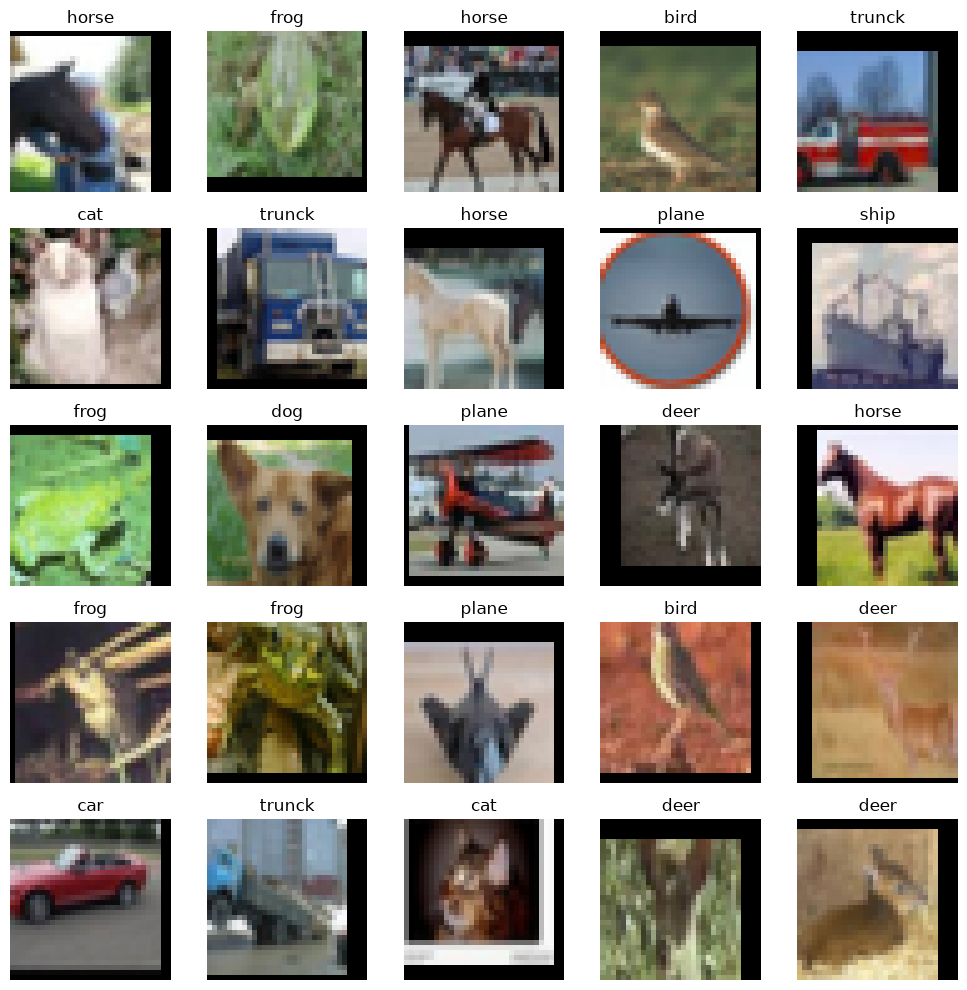

In [ ]:
figure = plt.figure(figsize=(10, 10))
rows, cols = 5, 5

for index in range(rows * cols):
    image = denormalize(images[index], mean, std)

    axis = figure.add_subplot(rows, cols, index + 1)
    axis.imshow(to_pil_image(image))
    axis.set_title(class_names[labels[index].item()])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes: int=10):
        super().__init__()

        self.features = nn.Sequential(
            # 입력 (128, 3, 32, 32)
            nn.Conv2d(3, 96, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 96, 16, 16)

            nn.Conv2d(96, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 출력 (128, 256, 8, 8)

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # 출력: (배치, 256, 4, 4)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256*4*4, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)

        x = torch.flatten(x, start_dim = 1)
        logits = self.classifier(x)
        return logits


### 왜 마지막에 Softmax를 넣지 않을까?
- nn.CrossEntropyLoss() 는 내부적으로 LogSoftmax와 NLLLoss를 결합해 계산함
- 모델의 마지막 층은 softmax 확률이 아니라 정규화되지 않은 점수인 로짓을 출력해야 함

```
logits = model(image)
loss = criterion(logits, labels)
# 예측 확률을 확인할 때만 아래와 같이 Softmax를 사용
probabilities = torch.softmax(logits, dim=1)
```

In [ ]:
model = AlexNetCIFAR10(num_classes=10).to(DEVICE)
print(model)

AlexNetCIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=Tr

In [ ]:
# parameter.numel(): 텐서안에 들어있는 원소의 개수를 구하는 함수
total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'전체 파라미터 수: {total_parameters}')

In [ ]:
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
print(f'학습 가능한 파라미터 수: {trainable_parameters}')

In [ ]:
# 더미 입력으로 각 단계의 크기 확인
dummy_input = torch.randn(2, 3, 32, 32).to(DEVICE)

with torch.inference_mode():
    feature_output = model.features(dummy_input)
    pooled_output = model.avgpool(feature_output)
    logits = model(dummy_input)

print('입력: ', dummy_input.shape)
print('합성곱 특징: ', feature_output.shape)
print('AdaptiveAvgPool 이후: ', pooled_output.shape)
print('최종 로짓: ', logits.shape)

### 손실 함수와 최적화 방법
- CrossEntropyLoss: 다중 클래스 분류에서 사용
- AdamW: Adam의 편리한 최적화와 weight decay를 분리해 적용
- ReduceLROnPlateau: 검증 손실이 개선되지 않을 대 학습률 감소

> AdamW가 항상 SGD보다 우수한 것은 아닙니다. 원본 AlexNet은 mementum을 작용한 SGD를 사용했습니다. 빠르게 실습 결과를 확인하기 위해 AdamW를 사용

In [ ]:
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# 학습 함수

In [ ]:
def train_one_epoch(data_loader, model, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

# 평가 함수

In [ ]:
def evaluate(data_loader, model, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

### 학습 및 최고 모델 저장
- 검증 손실이 가장 낮을 때의 가중치만 저장함
- 마지막 에포크의 모델이 항상 가장 좋은 모델은 아님
- 조기 종료는 검증 손실이 여러 에포크 동안 개선되지 않으면 학습을 끝내 과적합과 불필요한 연산을 줄임

In [ ]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / "alexnet_cifar10_best.pth"
EARLY_STOPPING_PATIENCE = 5

In [ ]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": []
}

best_validation_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        train_loader, model, criterion, optimizer, DEVICE
    )
    validation_loss, validation_accuracy = evaluate(
        validation_loader, model, criterion, DEVICE
    )
    scheduler.step(validation_loss)

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['validation_loss'].append(validation_loss)
    history['validation_accuracy'].append(validation_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f'Epoch [{epoch:02d}/{EPOCHS}]'
    f'lr={current_lr:.6f} | '
    f'train loss={train_loss:.4f}, acc={train_accuracy:.4f} | '
    f'val loss={validation_loss:.4f}, acc={validation_accuracy:.4f}'
    )

    if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f'최고 모델 저장: {BEST_MODEL_PATH}')
    else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print('조기 종료: 검증 손실이 더 이상 개선되지 않았습니다.')
                break

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs, history["validation_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# **2.Alexnet 모델 최종 평가**
- 학습과 모델 선택이 모두 끝난 뒤 저장해 둔 최고 모델을 불러옴
- 테스트 데이터는 최종 성능 확인에만 사용

In [ ]:
try:
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=True,
    )
except TypeError:
    best_state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(best_state_dict)

test_loss, test_accuracy = evaluate(
    test_loader, model, criterion, DEVICE
)

print(f"테스트 손실: {test_loss:.4f}")
print(f"테스트 정확도: {test_accuracy * 100:.2f}%")

### 혼동행렬과 클래스별 성능


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
def collect_predictions(data_loader, model, device,):
    model.eval()

    true_labels = []
    predicted_labels = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)

            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()

            true_labels.extend(labels.numpy().tolist())
            predicted_labels.extend(predictions.numpy().tolist())

    return np.array(true_labels), np.array(predicted_labels)


true_labels, predicted_labels = collect_predictions(
    test_loader, model, DEVICE
)

confusion = confusion_matrix(true_labels, predicted_labels)
confusion

In [ ]:
def plot_confusion_matrix(
    matrix,
    class_names,
    normalize: False,
):
    display_matrix = matrix.astype(float)

    if normalize:
        row_sums = display_matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(
            display_matrix,
            row_sums,
            out=np.zeros_like(display_matrix),
            where=row_sums != 0,
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(display_matrix, interpolation="nearest", cmap="Blues")
    plt.title("Normalized Confusion Matrix" if normalize else "Confusion Matrix")
    plt.colorbar()

    tick_positions = np.arange(len(class_names))
    plt.xticks(tick_positions, class_names, rotation=45)
    plt.yticks(tick_positions, class_names)

    threshold = display_matrix.max() / 2

    for row in range(display_matrix.shape[0]):
        for column in range(display_matrix.shape[1]):
            value = display_matrix[row, column]
            text = f"{value:.2f}" if normalize else f"{int(value)}"

            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(confusion, class_names, normalize=False)
plot_confusion_matrix(confusion, class_names, normalize=True)

In [ ]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)